In [1]:
!pip install yfinance statsmodels

In [2]:
# Written by Harshel Gopiinaath, last updated 06/09/2026
# z5764696@ad.unsw.edu.au
# A pair trading strategy backtester based on past data from the stock market

import yfinance as fins
import numpy as np
import statsmodels.api as stat
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plot
import pandas as pd

In [3]:
# Get data on two stocks via yfinance

ticker1 = "CBA.AX" # PICK ANY TICKER PAIR!
ticker2 = "WBC.AX"

data1 = fins.download(ticker1, start="2015-01-01", end="2024-01-01")
data2 = fins.download(ticker2, start="2015-01-01", end="2024-01-01")

close1 = data1["Close"][ticker1]
close2 = data2["Close"][ticker2]

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

In [4]:
# Test cointegration of our two stocks

score, p_value, _ = coint(close1, close2)
print(p_value)

0.9902029869527136


In [ ]:
# Check whether this pair actually clears a standard significance threshold for cointegration - the backtest below still runs either way (useful for comparing candidate pairs), but a low p-value means the pair is a good mean-reversion candidate.

ALPHA = 0.05
if p_value >= ALPHA:
    print(f"⚠️  WARNING: p-value = {p_value:.4f} >= {ALPHA} -- no statistically significant "
          f"cointegration found between {ticker1} and {ticker2}. Proceeding with the backtest "
          f"below anyway for comparison, but treat the results with caution.")
else:
    print(f"p-value = {p_value:.4f} < {ALPHA} -- {ticker1} and {ticker2} show statistically "
          f"significant cointegration.")

In [6]:
# Finding the hedge ratio of our stocks and converting the associated spread into a z-score

X = stat.add_constant(close2)
model = stat.OLS(close1, X).fit()
hedge_ratio = model.params.iloc[1]

spread = close1 - hedge_ratio * close2

In [7]:
# Conversion to z-score

window = 60 # days, can experiment with this
spread_mean = spread.rolling(window).mean()
spread_std = spread.rolling(window).std()
zscore = (spread - spread_mean) / spread_std

In [8]:
# IMPORTANT! Check our close1 data type (behaviour of Yahoo Finance data is different for different years)

print(data1.columns)
print(type(close1))

MultiIndex([( 'Close', 'CBA.AX'),
            (  'High', 'CBA.AX'),
            (   'Low', 'CBA.AX'),
            (  'Open', 'CBA.AX'),
            ('Volume', 'CBA.AX')],
           names=['Price', 'Ticker'])
<class 'pandas.Series'>


In [ ]:
# Backtest our trading based on these signals

positions = []
position = 0 # 0 is flat, 1 is long spread, -1 is short spread

for z in zscore:
    if position == 0:
        if z > 2:
            position = -1 # spread is wider than expected, short first and long second

        elif z < -2:
            position = 1 # spread is narrower than expected, long first and short second
    elif position == 1 and z >= 0:
        position = 0 # close our long position

    elif position == -1 and z <= 0:
        position = 0 # close our short position

    positions.append(position)

positions = pd.Series(positions, index=zscore.index)

spread_returns = spread.diff()
strategy_returns = positions.shift(1) * spread_returns
cumulative_returns = strategy_returns.cumsum()

# Annualise the Sharpe ratio to account for days traded (sqrt 252 as variance is additive and 252 days traded on market)
sharpe_ratio = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252)
max_drawdown = (cumulative_returns.cummax() - cumulative_returns).max()

print("Sharpe ratio (annualized):", sharpe_ratio)
print("Max drawdown:", max_drawdown)

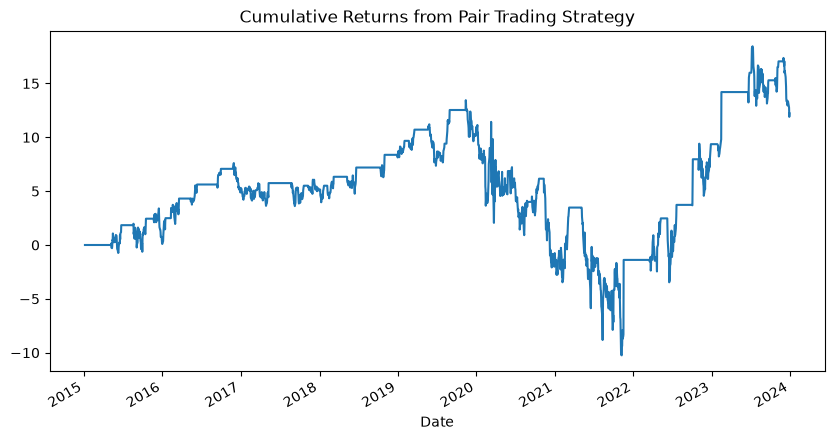

In [10]:
# Visualise our results using plots

plot.figure(figsize=(10, 5))
cumulative_returns.plot()
plot.title("Cumulative Returns from Pair Trading Strategy")
plot.show()